# Liberation Day: implied surfaces (OptionMetrics + VolForge) and noise-robust realized variance (TAQ)

One asset, a window of `N_BEFORE` trading days before and `N_AFTER` after the event date (default: 2025-04-02, "Liberation Day";
the tariffs were announced at 16:00 ET, after the close, so the first reaction session is 2025-04-03).

**Implied side.** OptionMetrics `opprcd` daily BBO (15:59 ET snapshot) → VolForge custom-data pipeline:
`ThetaDataCleaner` (generic column selection + bid/ask filters) → `Slicer` (forward and rate implied per expiry by put-call parity
regression, puts converted to calls, bid/ask Black IVs) → `LinearSurface`. Spot for the surface = TAQ microprice at 15:59:00,
synchronous with the option snapshot (OptionMetrics' own underlying price is the 16:00 close).

**Realized side.** TAQ `complete_nbbo`, day by day, 10:00–15:30 ET, microprice as reference price
(Deutsche Börse A7 definition: `mid + 0.5 * tick * (bq - aq) / (bq + aq)`). Two estimators per day:
- `rv_5m`: standard realized variance on the 5-minute calendar-time grid (realized-library);
- `rk_parzen`: non-flat-top Parzen realized kernel with optimal bandwidth (BNHLS 2009) — realized-library
  `non-flat-parzen`, falling back to `mfe.realized.realized_kernel(kernel_type=PARZEN)` if realized-library fails.
  The engine used is recorded per day.

Caveats: single-stock options are American; VolForge prices with Black on the parity-implied forward, so deep ITM quotes
carry some early-exercise premium. Realized measures cover 10:00–15:30 only (no overnight, no first/last 30 min).

In [1]:
from datetime import date, datetime, time
from pathlib import Path

import numpy as np
import polars as pl

from wrds_client.client import WRDSClient
from wrds_client.optionmetrics.option_prices import fetch_option_prices

# --- parameters -------------------------------------------------------------
# TICKER = "DECK" # Deckers Outdoor: Vietnam-sourced footwear, 46% Vietnam tariff on 2025-04-02
TICKER = "AAPL" # Apple Inc.: Technology company, 25% China tariff on 2025-04-02
EVENT_DATE = date(2025, 4, 2)
N_BEFORE, N_AFTER = 20, 30      # trading days
RTH_START, RTH_END = time(10, 0), time(15, 30)
OPTION_SNAPSHOT = time(15, 59)  # OptionMetrics BBO capture time since 2009-07-30
TICK_SIZE = 0.01                # Reg NMS Rule 612 tick for prices >= $1
RV_GRID = "5m"
LIQUIDITY_THRESHOLD = 0.5       # VolForge cleaner: drop quotes with (ask - bid) / mid >= threshold
ATM_TENOR_DAYS = 30

CACHE = Path(".cache") / f"{TICKER}_{EVENT_DATE:%Y%m%d}"
(CACHE / "taq").mkdir(parents=True, exist_ok=True)

wrds = WRDSClient.from_env()

Loading library list...
Done


## Trading days
From the TAQ daily table list (`taqm_YYYY.complete_nbbo_YYYYMMDD`), the authoritative calendar for the realized side.

In [2]:
libs = set(wrds.list_libraries())
taq_days = sorted(
    datetime.strptime(t.removeprefix("complete_nbbo_"), "%Y%m%d").date()
    for y in (EVENT_DATE.year - 1, EVENT_DATE.year, EVENT_DATE.year + 1)
    if f"taqm_{y}" in libs
    for t in wrds.list_tables(f"taqm_{y}")
    if t.startswith("complete_nbbo_") and len(t) == len("complete_nbbo_YYYYMMDD")
)
i_event = taq_days.index(EVENT_DATE)
DAYS = taq_days[i_event - N_BEFORE : i_event + N_AFTER + 1]
assert len(DAYS) == N_BEFORE + N_AFTER + 1, "window runs past the available TAQ days"
print(f"{len(DAYS)} trading days: {DAYS[0]} .. {DAYS[-1]} (event {EVENT_DATE})")

51 trading days: 2025-03-05 .. 2025-05-15 (event 2025-04-02)


## OptionMetrics: secid and daily option BBO

In [3]:
secid_row = wrds.raw_sql(
    "select secid, ticker, issuer, effect_date from optionm.secnmd "
    "where ticker = %(t)s and effect_date <= %(d)s order by effect_date desc limit 1",
    params={"t": TICKER, "d": EVENT_DATE},
)
SECID = int(secid_row["secid"][0])
print(secid_row.to_string(index=False))

om_path = CACHE / "optionmetrics_opprcd.parquet"
if om_path.exists():
    om = pl.read_parquet(om_path)
else:
    om = pl.from_pandas(fetch_option_prices(
        wrds, SECID, DAYS[0], DAYS[-1],
        columns=["secid", "date", "exdate", "cp_flag", "strike_price", "best_bid", "best_offer",
                 "volume", "open_interest", "impl_volatility", "ss_flag", "am_settlement",
                 "contract_size", "cfadj", "expiry_indicator"],
    ))
    om.write_parquet(om_path)
om = om.with_columns(pl.col("date", "exdate").cast(pl.Date))
print(om.shape)
om.group_by("date").agg(pl.len().alias("n_options"), pl.col("exdate").n_unique().alias("n_expiries")).sort("date").head()

    secid ticker    issuer effect_date
 101594.0   AAPL APPLE INC  2020-08-03
(120660, 15)


date,n_options,n_expiries
date,u32,u32
2025-03-05,2264,20
2025-03-06,2322,21
2025-03-07,2350,21
2025-03-10,2252,20
2025-03-11,2324,20


Map to VolForge's `OptionSliceSchema`. Keep standard contracts only: no special settlement (`ss_flag = '0'`),
PM-settled, 100-share deliverable, no corporate-action adjustment (`cfadj = 1`). Strike is stored ×1000 in OptionMetrics.

In [4]:
quotes = (
    om.filter(
        pl.col("ss_flag") == "0",
        pl.col("am_settlement") == 0,
        pl.col("contract_size") == 100,
        pl.col("cfadj") == 1,
    )
    .select(
        pl.col("date"),
        pl.lit(TICKER).alias("symbol"),
        pl.col("exdate").alias("expiration"),
        (pl.col("strike_price") / 1000).cast(pl.Float64).alias("strike"),
        pl.when(pl.col("cp_flag") == "C").then(pl.lit("CALL")).otherwise(pl.lit("PUT")).alias("right"),
        pl.col("best_bid").cast(pl.Float64).alias("bid"),
        pl.col("best_offer").cast(pl.Float64).alias("ask"),
        pl.lit(None, dtype=pl.Float64).alias("close"),
        pl.col("volume").cast(pl.Float64),
        pl.lit(None, dtype=pl.Float64).alias("bid_size"),
        pl.lit(None, dtype=pl.Float64).alias("ask_size"),
    )
)
print(f"{quotes.height} standard quotes of {om.height}")

120660 standard quotes of 120660


## TAQ: microprice, day by day
One query per day on `complete_nbbo_YYYYMMDD`, filtered to the symbol and the 10:00–15:30 window; cached per day. A second, tiny query takes the last NBBO at or before 15:59:00 as the surface spot.

In [5]:
NBBO_COLS = (
    "(extract(epoch from time_m) * 1000000000)::bigint + coalesce(time_m_nano, 0) as tod_ns, "
    "best_bid, best_bidsizeshares as bq, best_ask, best_asksizeshares as aq"
)

def _microprice(df: pl.DataFrame) -> pl.DataFrame:
    # Deutsche Börse A7: mid + 0.5 * tick * (bq - aq) / (bq + aq); prices already in dollars
    return (
        df.filter(pl.col("best_bid") > 0, pl.col("best_ask") > pl.col("best_bid"), pl.col("bq") > 0, pl.col("aq") > 0)
        .with_columns(
            (0.5 * (pl.col("best_bid") + pl.col("best_ask"))
             + 0.5 * TICK_SIZE * (pl.col("bq") - pl.col("aq")) / (pl.col("bq") + pl.col("aq"))).alias("microprice")
        )
    )

def taq_day(d: date) -> pl.DataFrame:
    path = CACHE / "taq" / f"{d:%Y%m%d}.parquet"
    if path.exists():
        return pl.read_parquet(path)
    raw = wrds.raw_sql(
        f"select {NBBO_COLS} from taqm_{d.year}.complete_nbbo_{d:%Y%m%d} "
        "where sym_root = %(s)s and sym_suffix is null and time_m between %(t0)s and %(t1)s order by time_m, time_m_nano",
        params={"s": TICKER, "t0": RTH_START, "t1": RTH_END},
    )
    midnight_ns = int(np.datetime64(d, "ns").astype("int64"))  # naive ET wall clock, only differences matter
    df = (
        _microprice(pl.from_pandas(raw).with_columns(pl.col("best_bid", "best_ask").cast(pl.Float64), pl.col("bq", "aq").cast(pl.Float64)))
        .with_columns((pl.col("tod_ns") + midnight_ns).alias("ts_ns"))
        .unique("ts_ns", keep="last", maintain_order=True)   # one price per timestamp
        .select(pl.lit(d).alias("date"), "ts_ns", "best_bid", "best_ask", "bq", "aq", "microprice")
    )
    df.write_parquet(path)
    return df

def spot_at_snapshot(d: date) -> float:
    raw = wrds.raw_sql(
        f"select {NBBO_COLS} from taqm_{d.year}.complete_nbbo_{d:%Y%m%d} "
        "where sym_root = %(s)s and sym_suffix is null and time_m <= %(t)s and best_bid > 0 and best_ask > best_bid "
        "order by time_m desc, time_m_nano desc limit 1",
        params={"s": TICKER, "t": OPTION_SNAPSHOT},
    )
    return float(_microprice(pl.from_pandas(raw).with_columns(pl.col("best_bid", "best_ask", "bq", "aq").cast(pl.Float64)))["microprice"][0])

taq = {d: taq_day(d) for d in DAYS}
spot_path = CACHE / "spot_1559.parquet"
if spot_path.exists():
    spots = dict(pl.read_parquet(spot_path).iter_rows())
else:
    spots = {d: spot_at_snapshot(d) for d in DAYS}
    pl.DataFrame({"date": list(spots), "spot": list(spots.values())}).write_parquet(spot_path)
pl.DataFrame({"date": DAYS, "n_quotes": [taq[d].height for d in DAYS], "spot_1559": [spots[d] for d in DAYS]}).head()

date,n_quotes,spot_1559
date,i64,f64
2025-03-05,517113,235.614
2025-03-06,727688,235.1925
2025-03-07,894575,239.396111
2025-03-10,1113793,227.435
2025-03-11,1260845,221.22625


## VolForge: one surface per day
`surfaces[d]` keeps the `LinearSurface` objects; `surface_points` stacks every day's market implied vols (one row per date × expiry × strike) and `slice_info` the per-expiry forward and implied rate.

In [6]:
from vol_forge.slicer.slicer import DEFAULT_FALLBACK_RATE, Slicer
from vol_forge.surface.linear_surface import LinearSurface
from vol_forge.theta_data.theta_data_cleaner import ThetaDataCleaner

cleaner = ThetaDataCleaner(liquidity_threshold=LIQUIDITY_THRESHOLD)
surfaces: dict[date, LinearSurface] = {}
points, slice_rows, skipped = [], [], []

for d in DAYS:
    day_quotes = quotes.filter(pl.col("date") == d).drop("date")
    if day_quotes.is_empty():
        skipped.append((d, "no OptionMetrics quotes"))
        continue
    slices = Slicer(base_date=d).construct_slices(cleaner.clean(day_quotes))
    if len(slices) < 2:
        skipped.append((d, f"{len(slices)} usable expiries"))
        continue
    surface = LinearSurface.construct_from_slices(base_date=d, spot=spots[d], slices=slices)
    surfaces[d] = surface
    day_slices = pl.DataFrame([
        {"date": d, "expiry": s.expiry_date, "ttm": s.ttm, "forward": s.forward, "rate": s.rate, "n_strikes": len(s.mids)}
        for s in slices
    ])
    slice_rows.append(day_slices)
    points.append(
        surface.get_market_implied_vols()                      # columns ttm, strike, bid, ask, mid: implied vols
        .rename({"bid": "iv_bid", "ask": "iv_ask", "mid": "iv_mid"})
        .with_columns(pl.lit(d).alias("date"))
        .join(day_slices.select("date", "ttm", "expiry", "forward"), on=["date", "ttm"], how="left")
        .select("date", "expiry", "ttm", "forward", "strike", "iv_bid", "iv_mid", "iv_ask")
    )

surface_points = pl.concat(points, how="diagonal_relaxed")
# rate_is_fallback: the parity regression's rate fell outside rate_bounds and Slicer used its fallback (0.04)
slice_info = pl.concat(slice_rows).with_columns((pl.col("rate") == DEFAULT_FALLBACK_RATE).alias("rate_is_fallback"))
surface_points.write_parquet(CACHE / "surface_points.parquet")
slice_info.write_parquet(CACHE / "slice_info.parquet")
print(f"{len(surfaces)} surfaces, {surface_points.height} points; skipped: {skipped}")
surface_points

Unable to construct slice for 2025-03-07 as options are maturing within less than a day. Skipping maturity date
Unable to construct slice for 2025-03-14 as options are maturing within less than a day. Skipping maturity date
Unable to construct slice for 2025-03-21 as options are maturing within less than a day. Skipping maturity date
Unable to construct slice for 2025-03-28 as options are maturing within less than a day. Skipping maturity date
Unable to construct slice for 2025-04-04 as options are maturing within less than a day. Skipping maturity date
Unable to construct slice for 2025-04-11 as options are maturing within less than a day. Skipping maturity date
Unable to construct slice for 2025-04-17 as options are maturing within less than a day. Skipping maturity date
Unable to construct slice for 2025-04-25 as options are maturing within less than a day. Skipping maturity date
Unable to construct slice for 2025-05-02 as options are maturing within less than a day. Skipping maturi

51 surfaces, 52182 points; skipped: []


date,expiry,ttm,forward,strike,iv_bid,iv_mid,iv_ask
date,date,f64,f64,f64,f64,f64,f64
2025-03-05,2025-03-07,0.005479,235.745711,257.5,0.448894,0.448894,0.448894
2025-03-05,2025-03-07,0.005479,235.745711,260.0,0.492465,0.492465,0.492465
2025-03-05,2025-03-07,0.005479,235.745711,265.0,0.577233,0.577233,0.577233
2025-03-05,2025-03-07,0.005479,235.745711,170.0,1.49607,1.49607,1.49607
2025-03-05,2025-03-07,0.005479,235.745711,175.0,1.372938,1.372938,1.372938
…,…,…,…,…,…,…,…
2025-05-15,2027-12-17,2.591781,228.779841,420.0,0.248582,0.250353,0.252124
2025-05-15,2027-12-17,2.591781,228.779841,425.0,0.24872,0.250376,0.252032
2025-05-15,2027-12-17,2.591781,228.779841,430.0,0.249033,0.250467,0.251901


In [7]:
# ATM-forward implied vol at a fixed tenor, read off each day's surface (NaN if the tenor is outside the quoted range)
T_ATM = ATM_TENOR_DAYS / 365
atm = pl.DataFrame([
    {"date": d, "forward_atm": float(s.forward_curve.get_forward(T_ATM)),
     f"iv_atm_{ATM_TENOR_DAYS}d": float(np.asarray(s.get_iv([T_ATM], [float(s.forward_curve.get_forward(T_ATM))])).ravel()[0])}
    for d, s in surfaces.items()
])
atm.head()

date,forward_atm,iv_atm_30d
date,f64,f64
2025-03-05,236.596652,0.278487
2025-03-06,236.041832,0.297561
2025-03-07,240.297651,0.274431
2025-03-10,228.267104,0.354815
2025-03-11,222.124295,0.353901


## Realized measures, 10:00–15:30

realized-library first; if it cannot be imported (or fails on a day), the kernel falls back to
`mfe.realized.realized_kernel` with the Parzen kernel (k(h/(H+1)) weights, c* = 3.51, H* = c*·ξ^(4/5)·n^(3/5)),
without mfe's −2ω̂² "jitter" subtraction so the value stays the plain kernel sum. The engine is recorded per day.

In [8]:
from realized_library.estimators.variance.realized_variance import compute as rl_rv
from realized_library.utils.resampling import compute as rl_resample

try:
    from realized_library.estimators.variance import integrated_variance as rl_iv
    from realized_library.estimators.variance import noise_variance as rl_noise
    from realized_library.estimators.variance import realized_kernel as rl_rk
    RL_KERNEL_ERROR = None
except Exception as exc:  # noqa: BLE001 - recorded and reported, the fallback takes over
    RL_KERNEL_ERROR = f"{type(exc).__name__}: {exc}"
print("realized-library kernel:", "available" if RL_KERNEL_ERROR is None else f"unavailable ({RL_KERNEL_ERROR}) -> mfe fallback")

from mfe.realized import realized_kernel as mfe_rk
from mfe.realized._types import KernelType


def rv_grid(prices: np.ndarray, ts: np.ndarray) -> float:
    p, _ = rl_resample(prices, ts, RV_GRID, ffill=True)
    p = p[~np.isnan(p)]
    return float(rl_rv(p))


def rk_realized_library(prices: np.ndarray, ts: np.ndarray) -> dict:
    q = rl_noise.optimal_q(ts, target_time_interval=120)
    omega2 = float(rl_noise.compute(prices, q=q))
    iv = float(rl_iv.compute(prices, ts, sample_size="20m", offset="1s"))
    n = len(prices) - 1
    H = max(1, int(np.ceil(rl_rk.optimal_bandwidth("non-flat-parzen", n=n, omega2_est=omega2, iq_est=iv**2))))
    return {"rk_parzen": float(rl_rk.compute(prices, bandwidth=H, kernel="non-flat-parzen")),
            "bandwidth": H, "omega2": omega2, "engine": "realized-library"}


def rk_mfe(prices: np.ndarray) -> dict:
    res = mfe_rk(np.diff(np.log(prices)), kernel_type=KernelType.PARZEN, bandwidth=None, jitter=False)
    return {"rk_parzen": float(res.rk), "bandwidth": int(res.bandwidth), "omega2": float(res.noise_variance), "engine": "mfe"}


rows = []
for d in DAYS:
    day = taq[d]
    prices, ts = day["microprice"].to_numpy(), day["ts_ns"].to_numpy()
    out = {"date": d, "n_quotes": len(prices), "rv_5m": rv_grid(prices, ts)}
    if RL_KERNEL_ERROR is None:
        try:
            out |= rk_realized_library(prices, ts)
        except Exception as exc:  # noqa: BLE001
            out |= rk_mfe(prices) | {"engine": f"mfe (realized-library failed: {type(exc).__name__})"}
    else:
        out |= rk_mfe(prices)
    rows.append(out)

realized = pl.DataFrame(rows).with_columns(
    # annualised from the 10:00-15:30 window only: comparable across days, not a full-day vol
    (pl.col("rv_5m") * 252).sqrt().alias("vol_rv_5m_ann"),
    (pl.col("rk_parzen") * 252).sqrt().alias("vol_rk_parzen_ann"),
)
realized.write_parquet(CACHE / "realized.parquet")
realized

realized-library kernel: unavailable (ImportError: cannot import name 'simps' from 'scipy.integrate' (/home/luxor/Programming/PhD/PhD-Narrative-Finance/python/.venv/lib/python3.12/site-packages/scipy/integrate/__init__.py)) -> mfe fallback


date,n_quotes,rv_5m,rk_parzen,bandwidth,omega2,engine,vol_rv_5m_ann,vol_rk_parzen_ann
date,i64,f64,f64,i64,f64,str,f64,f64
2025-03-05,517113,0.000312,0.000168,9,1.1341e-11,"""mfe""",0.280622,0.205924
2025-03-06,727688,0.000192,0.000176,12,8.1795e-12,"""mfe""",0.220139,0.210769
2025-03-07,894575,0.000231,0.000188,14,1.0330e-11,"""mfe""",0.241222,0.217585
2025-03-10,1113793,0.000288,0.000217,11,4.5312e-12,"""mfe""",0.269211,0.2337
2025-03-11,1260845,0.000526,0.000277,14,9.2862e-12,"""mfe""",0.36391,0.26413
…,…,…,…,…,…,…,…,…
2025-05-09,397617,0.000094,0.000088,13,1.4441e-11,"""mfe""",0.153529,0.148818
2025-05-12,298885,0.000108,0.000077,11,1.0912e-11,"""mfe""",0.164793,0.139589
2025-05-13,350261,0.000075,0.000061,10,5.6427e-12,"""mfe""",0.137205,0.123761


### Diagnostic: RV signature and kernel bandwidth

On the probe days (2025-04-01 and 2025-04-03) the microprice RV signature *rises* from 1s to ~1m before flattening:
positive high-frequency autocorrelation (stale / gradually adjusting quotes), not bid-ask bounce. The Bandi-Russell noise
estimate (−½·acov₁) behind the automatic bandwidth then collapses, H* comes out at 8–10, and the Parzen kernel lands
~40% below the RV plateau; it only reaches it around H ≈ 64–128. Check this table before trusting `rk_parzen` on the full window.

In [9]:
SIG_GRIDS = ["1s", "10s", "30s", "1m", "2m", "5m", "10m", "15m"]
RK_BANDWIDTHS = [16, 32, 64, 128]

sig_rows = []
for d in DAYS:
    prices, ts = taq[d]["microprice"].to_numpy(), taq[d]["ts_ns"].to_numpy()
    row = {"date": d}
    for g in SIG_GRIDS:
        p, _ = rl_resample(prices, ts, g, ffill=True)
        row[f"rv_{g}"] = float(rl_rv(p[~np.isnan(p)]))
    r = np.diff(np.log(prices))
    for H in RK_BANDWIDTHS:
        row[f"rk_H{H}"] = float(mfe_rk(r, kernel_type=KernelType.PARZEN, bandwidth=H, jitter=False).rk)
    sig_rows.append(row)

signature = pl.DataFrame(sig_rows).join(realized.select("date", "rk_parzen", "bandwidth"), on="date")
# ratios to the 5-minute RV: a flat row means the estimators agree
signature.select("date", "bandwidth", *[(pl.col(c) / pl.col("rv_5m")).round(2).alias(c) for c in signature.columns if c.startswith(("rv_", "rk_"))])

date,bandwidth,rv_1s,rv_10s,rv_30s,rv_1m,rv_2m,rv_5m,rv_10m,rv_15m,rk_H16,rk_H32,rk_H64,rk_H128,rk_parzen
date,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-03-05,9,0.86,0.92,0.91,0.93,0.97,1.0,1.15,1.55,0.61,0.72,0.8,0.85,0.54
2025-03-06,12,1.25,1.28,1.14,1.03,0.86,1.0,0.97,0.62,0.97,1.09,1.18,1.23,0.92
2025-03-07,14,1.09,1.11,1.05,0.91,0.98,1.0,0.92,0.48,0.84,0.95,1.04,1.08,0.81
2025-03-10,11,1.07,1.06,1.05,0.97,0.94,1.0,0.8,0.83,0.82,0.93,1.01,1.06,0.75
2025-03-11,14,0.71,0.75,0.78,0.82,0.79,1.0,0.67,0.65,0.54,0.61,0.67,0.72,0.53
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-05-09,13,1.25,1.46,1.42,1.1,1.11,1.0,0.89,0.81,0.97,1.06,1.14,1.22,0.94
2025-05-12,11,1.01,1.1,1.13,1.13,1.06,1.0,0.73,0.75,0.76,0.87,0.99,1.1,0.72
2025-05-13,10,1.07,1.09,1.11,1.18,0.96,1.0,0.78,0.76,0.87,0.96,1.04,1.08,0.81


## Daily panel

In [10]:
daily = (
    realized.join(atm, on="date", how="left")
    .with_columns((pl.col("date") > EVENT_DATE).alias("post_event"))
    .sort("date")
)
daily.write_parquet(CACHE / "daily.parquet")
daily.select("date", "post_event", "n_quotes", "vol_rv_5m_ann", "vol_rk_parzen_ann", f"iv_atm_{ATM_TENOR_DAYS}d", "bandwidth", "engine")

date,post_event,n_quotes,vol_rv_5m_ann,vol_rk_parzen_ann,iv_atm_30d,bandwidth,engine
date,bool,i64,f64,f64,f64,i64,str
2025-03-05,false,517113,0.280622,0.205924,0.278487,9,"""mfe"""
2025-03-06,false,727688,0.220139,0.210769,0.297561,12,"""mfe"""
2025-03-07,false,894575,0.241222,0.217585,0.274431,14,"""mfe"""
2025-03-10,false,1113793,0.269211,0.2337,0.354815,11,"""mfe"""
2025-03-11,false,1260845,0.36391,0.26413,0.353901,14,"""mfe"""
…,…,…,…,…,…,…,…
2025-05-09,true,397617,0.153529,0.148818,0.314267,13,"""mfe"""
2025-05-12,true,298885,0.164793,0.139589,0.257991,11,"""mfe"""
2025-05-13,true,350261,0.137205,0.123761,0.257774,10,"""mfe"""


<Axes: title={'center': 'AAPL realized vs implied vol (event 2025-04-02)'}, xlabel='date', ylabel='volatility'>

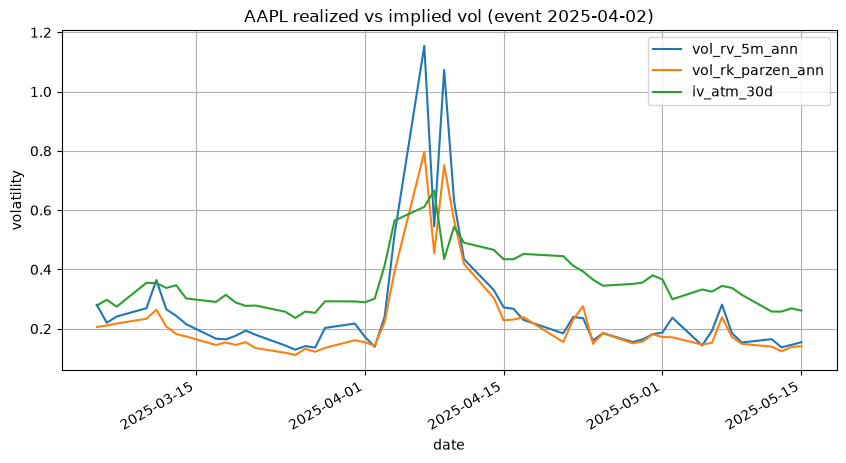

In [11]:
daily["date", "vol_rv_5m_ann", "vol_rk_parzen_ann", "iv_atm_30d"].to_pandas().set_index("date").plot(title=f"{TICKER} realized vs implied vol (event {EVENT_DATE})", figsize=(10, 5), grid=True, ylabel="volatility", xlabel="date")

In [12]:
wrds.close()